In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Load the dataset**

In [38]:
df = pd.read_csv("talabat_enhanced_orders.csv")

df.head()
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 23 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Order_ID                   100000 non-null  int64  
 1   User_ID                    100000 non-null  object 
 2   Restaurant_ID              100000 non-null  int64  
 3   Driver_ID                  100000 non-null  int64  
 4   Item_Name                  100000 non-null  object 
 5   Quantity                   100000 non-null  int64  
 6   Total_Price                100000 non-null  float64
 7   Order_Time                 100000 non-null  object 
 8   Delivery_Time              100000 non-null  object 
 9   Delivery_Duration_Minutes  100000 non-null  int64  
 10  City                       100000 non-null  object 
 11  Payment_Method             100000 non-null  object 
 12  Order_Status               100000 non-null  object 
 13  Driver_Vehicle             100

**Data Preprocessing**

In [40]:
# make a copy
df = df.copy()

# check missing values
print(df.isnull().sum())

# check duplicates
print("Duplicate rows:", df.duplicated().sum())

# remove duplicates if any
df = df.drop_duplicates()

# convert datetime columns
df['Order_Time'] = pd.to_datetime(df['Order_Time'], format='%d-%m-%Y %H:%M')
df['Delivery_Time'] = pd.to_datetime(df['Delivery_Time'], format='%d-%m-%Y %H:%M')

# create time-based features
df['order_hour'] = df['Order_Time'].dt.hour
df['order_day'] = df['Order_Time'].dt.day
df['order_month'] = df['Order_Time'].dt.month
df['order_weekday'] = df['Order_Time'].dt.weekday
df['is_weekend'] = df['order_weekday'].isin([5, 6]).astype(int)

# create delivery duration from timestamps
df['calculated_delivery_duration_mins'] = (
    (df['Delivery_Time'] - df['Order_Time']).dt.total_seconds() / 60
)

# keep only realistic values
df = df[df['calculated_delivery_duration_mins'] >= 0]
df = df[df['Delivery_Distance_km'] >= 0]

# keep only delivered orders
df = df[df['Order_Status'] == 'Delivered']

# check result
print(df.shape)
df.head()

Order_ID                     0
User_ID                      0
Restaurant_ID                0
Driver_ID                    0
Item_Name                    0
Quantity                     0
Total_Price                  0
Order_Time                   0
Delivery_Time                0
Delivery_Duration_Minutes    0
City                         0
Payment_Method               0
Order_Status                 0
Driver_Vehicle               0
Restaurant_Lat               0
Restaurant_Lon               0
Customer_Lat                 0
Customer_Lon                 0
Driver_Lat                   0
Driver_Lon                   0
Delivery_Distance_km         0
Traffic_Level                0
Driver_Availability          0
dtype: int64
Duplicate rows: 0
(85197, 29)


,Order_ID,User_ID,Restaurant_ID,Driver_ID,Item_Name,Quantity,Total_Price,Order_Time,Delivery_Time,Delivery_Duration_Minutes,...,Driver_Lon,Delivery_Distance_km,Traffic_Level,Driver_Availability,order_hour,order_day,order_month,order_weekday,is_weekend,calculated_delivery_duration_mins
0,1,U3522,358,485,Fried Chicken,3,273.72,2025-06-16 08:32:00,2025-06-16 09:11:00,39,...,29.910664,1.666106,High,Offline,8,16,6,0,0,39.0
1,2,U9214,316,65,Sandwich,3,365.82,2025-06-03 21:27:00,2025-06-03 22:00:00,33,...,31.502380,2.738698,Low,Online,21,3,6,1,0,33.0
3,4,U3612,420,32,Sushi,2,221.18,2025-06-13 02:30:00,2025-06-13 03:22:00,52,...,31.401187,0.677498,Low,Online,2,13,6,4,0,52.0
4,5,U3492,73,364,Koshary,5,355.55,2025-06-06 09:48:00,2025-06-06 10:32:00,44,...,31.389315,1.994769,High,Online,9,6,6,4,0,44.0
5,6,U7439,750,270,Sushi,3,205.44,2025-06-04 12:16:00,2025-06-04 12:45:00,29,...,31.380646,1.436807,Medium,Online,12,4,6,2,0,29.0


**Create ZONES (Nodes)**

In [42]:
df['zone'] = (
    df['Restaurant_Lat'].round(2).astype(str) + "_" +
    df['Restaurant_Lon'].round(2).astype(str)
)

print("Zones:", df['zone'].nunique())

Zones: 171


**Create DEMAND (Target)**

In [44]:
demand_df = df.groupby(['zone', 'order_hour']).size().reset_index(name='demand')

demand_df.head()

,zone,order_hour,demand
0,27.16_31.16,0,1
1,27.16_31.16,1,3
2,27.16_31.16,2,3
3,27.16_31.16,3,1
4,27.16_31.16,4,2


**Create NODE FEATURES**

In [46]:
zone_features = df.groupby('zone').agg({
    'Delivery_Distance_km': 'mean',
    'calculated_delivery_duration_mins': 'mean',
    'Total_Price': 'mean'
}).reset_index()

zone_features.head()

,zone,Delivery_Distance_km,calculated_delivery_duration_mins,Total_Price
0,27.16_31.16,3.031954,37.857143,301.815000
1,27.16_31.17,2.810745,37.633758,275.358694
2,27.16_31.18,2.430143,37.267101,273.417752
3,27.16_31.19,2.691625,37.415808,264.355361
4,27.16_31.2,2.759820,37.928826,276.682420


**Create zone index**

In [48]:
zone_to_idx = {zone: i for i, zone in enumerate(zone_features['zone'])}
zone_features['zone_idx'] = zone_features['zone'].map(zone_to_idx)

zone_features.head()

,zone,Delivery_Distance_km,calculated_delivery_duration_mins,Total_Price,zone_idx
0,27.16_31.16,3.031954,37.857143,301.815000,0
1,27.16_31.17,2.810745,37.633758,275.358694,1
2,27.16_31.18,2.430143,37.267101,273.417752,2
3,27.16_31.19,2.691625,37.415808,264.355361,3
4,27.16_31.2,2.759820,37.928826,276.682420,4


**Create graph edges**

In [50]:
edges = []

for city in df['City'].unique():
    city_zones = df[df['City'] == city]['zone'].unique()
    
    for i in range(len(city_zones)):
        for j in range(i + 1, len(city_zones)):
            edges.append((zone_to_idx[city_zones[i]], zone_to_idx[city_zones[j]]))
            edges.append((zone_to_idx[city_zones[j]], zone_to_idx[city_zones[i]]))

edge_index = np.array(edges).T

print("Edge index shape:", edge_index.shape)

Edge index shape: (2, 4200)


**Create feature matrix X**

In [110]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = scaler.fit_transform(zone_features[['Delivery_Distance_km',
                                        'calculated_delivery_duration_mins',
                                        'Total_Price']])

print(X[:5])
print(X.shape)

[[ 1.77002112  0.39660173  2.93559111]
 [ 1.21021582  0.06205423  0.5376901 ]
 [ 0.24704528 -0.48706157  0.36177037]
 [ 0.90876496 -0.26435441 -0.45961105]
 [ 1.08134308  0.50395585  0.65766767]]
(171, 3)


**Create target y**

In [112]:
zone_demand = demand_df.groupby('zone')['demand'].mean().reset_index()
zone_demand['zone_idx'] = zone_demand['zone'].map(zone_to_idx)
zone_demand = zone_demand.sort_values('zone_idx')

y = zone_demand['demand'].values

print("y shape:", y.shape)

y shape: (171,)


In [114]:
import torch
import torch_geometric

**Convert your data into tensors**

In [116]:
import torch

X_tensor = torch.tensor(X, dtype=torch.float)
y_tensor = torch.tensor(y, dtype=torch.float)
edge_index_tensor = torch.tensor(edge_index, dtype=torch.long)

print("X tensor shape:", X_tensor.shape)
print("y tensor shape:", y_tensor.shape)
print("edge_index tensor shape:", edge_index_tensor.shape)

X tensor shape: torch.Size([171, 3])
y tensor shape: torch.Size([171])
edge_index tensor shape: torch.Size([2, 4200])


**Create the graph data object**

In [118]:
from torch_geometric.data import Data

data = Data(x=X_tensor, edge_index=edge_index_tensor, y=y_tensor)

print(data)

Data(x=[171, 3], edge_index=[2, 4200], y=[171])


**Create training and testing masks**

In [120]:
num_nodes = data.num_nodes
num_train = int(num_nodes * 0.8)

perm = torch.randperm(num_nodes)

train_idx = perm[:num_train]
test_idx = perm[num_train:]

data.train_mask = torch.zeros(num_nodes, dtype=torch.bool)
data.test_mask = torch.zeros(num_nodes, dtype=torch.bool)

data.train_mask[train_idx] = True
data.test_mask[test_idx] = True

print("Training nodes:", data.train_mask.sum().item())
print("Testing nodes:", data.test_mask.sum().item())

Training nodes: 136
Testing nodes: 35


**Define the GAT model**

In [122]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GATConv

class GATModel(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads=2):
        super().__init__()
        
        # First GAT layer
        self.gat1 = GATConv(in_channels, hidden_channels, heads=heads)
        
        # Second GAT layer
        self.gat2 = GATConv(hidden_channels * heads, out_channels, heads=1, concat=False)

    def forward(self, x, edge_index):
        x = self.gat1(x, edge_index)
        x = F.relu(x)
        x = self.gat2(x, edge_index)
        return x

**Create the model object**

In [124]:
model = GATModel(in_channels=3, hidden_channels=8, out_channels=1)
print(model)

GATModel(
  (gat1): GATConv(3, 8, heads=2)
  (gat2): GATConv(16, 1, heads=1)
)


**Set optimizer and loss**

In [126]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = torch.nn.MSELoss()

**Train the model**

In [128]:
model.train()
losses = []

for epoch in range(1, 201):
    optimizer.zero_grad()
    
    out = model(data.x, data.edge_index).squeeze()
    
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    
    loss.backward()
    optimizer.step()
    
    losses.append(loss.item())
    
    if epoch % 20 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Epoch 20, Loss: 425.7450
Epoch 40, Loss: 185.4235
Epoch 60, Loss: 139.6882
Epoch 80, Loss: 132.4034
Epoch 100, Loss: 130.2759
Epoch 120, Loss: 128.9412
Epoch 140, Loss: 127.7761
Epoch 160, Loss: 126.8053
Epoch 180, Loss: 126.1056
Epoch 200, Loss: 125.6775


**Evaluate the model**

In [130]:
model.eval()

with torch.no_grad():
    pred = model(data.x, data.edge_index).squeeze()
    test_loss = criterion(pred[data.test_mask], data.y[data.test_mask])

print("Test Loss:", test_loss.item())

Test Loss: 134.5160369873047


**Check actual vs predicted values**

In [132]:
actual = data.y[data.test_mask].cpu().numpy()
predicted = pred[data.test_mask].cpu().numpy()

print("Actual:", actual[:10])
print("Predicted:", predicted[:10])

Actual: [30.916666  27.333334   4.4166665 31.583334  28.916666   5.9166665
 15.166667   1.        32.541668  29.666666 ]
Predicted: [19.142231 19.142227 19.142227 19.14223  19.142227 22.052555 22.50714
 23.220505 23.220509 23.220507]


**Plot the training loss**

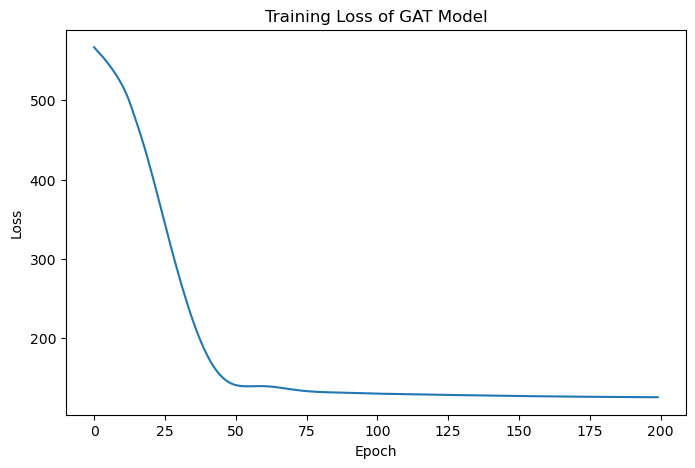

In [134]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss of GAT Model")
plt.show()

**Apply Feature Scaling**